In [1]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())

DATASETS_DIR = PROJECT_ROOT / "data" / "datasets_clean" / "generalization"
RESULTS_DIR = PROJECT_ROOT / "data" / "results_clean" / "generalization"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Add project root to the Python path
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods.mdp_clean import DiscreteMDP, Planner
from rl_methods.fogas_clean import FOGASEvaluator, FOGASHyperOptimizer
from rl_methods.fogas_generalization_clean import *
from rl_methods.sbeed import (
    DiscreteSBEED,
    DiscreteSBEEDDataset,
    LinearValueParam,
    LinearRhoParam,
    SoftmaxLinearPolicyParam,
    TabularStateFeatures,
    TabularStateActionFeatures,
)
from rl_methods.data_collection_clean import DiscreteDataBuffer

/home/mauro/anaconda3/envs/fogas/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3grid empty

In [2]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9
x_0 = 0

dataset_path = DATASETS_DIR / "3grid.csv"
goal_grid = 8


def phi(x, a):
    vec = torch.zeros(N * A, dtype=torch.float64, device=DEVICE)
    vec[int(x) * A + int(a)] = 1.0
    return vec


omega = torch.full(
    (N * A,),
    -0.1,
    dtype=torch.float64,
    device=DEVICE,
)
omega[goal_grid * A : goal_grid * A + A] = 1.0


def to_rc(s):
    return divmod(int(s), 3)


def to_s(r, c):
    return r * 3 + c


def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal_grid:
        return goal_grid

    r, c = to_rc(s)

    if a == 0:      # Up
        r = max(0, r - 1)
    elif a == 1:    # Down
        r = min(2, r + 1)
    elif a == 2:    # Left
        c = max(0, c - 1)
    elif a == 3:    # Right
        c = min(2, c + 1)

    return to_s(r, c)


def psi(xp):
    v = torch.zeros(N * A, dtype=torch.float64, device=DEVICE)
    for x in states:
        for a in actions:
            if next_state(x, a) == int(xp):
                v[int(x) * A + int(a)] = 1.0
    return v


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    phi=phi,
    omega=omega,
    psi=psi,
    terminal_states=[goal_grid],
).to(DEVICE)

planner = Planner(mdp)

In [5]:
# Load your fixed offline dataset.
df = pd.read_csv(dataset_path)

done = df["next_state"].astype(int).eq(goal_grid).to_numpy()

dataset = DiscreteSBEEDDataset(
    X=df["state"].to_numpy(),
    A=df["action"].to_numpy(),
    R=df["reward"].to_numpy(),
    X_next=df["next_state"].to_numpy(),
    D=done,
)

value_features = TabularStateFeatures(N)
rho_features = TabularStateActionFeatures(N, A)

solver_sbeed = DiscreteSBEED(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_param=LinearValueParam(value_features, N),
    rho_param=LinearRhoParam(rho_features, N, A),
    policy_param=SoftmaxLinearPolicyParam(value_features, N, A),
    lambda_entropy=0.01,
    eta=1.0,
    lr_value=1e-2,
    lr_rho=1e-2,
    lr_policy=1e-2,
    tau=500.0,
    max_buffer_size=len(df),
    batch_size=None,
    rollout_length=1,
    seed=42,
    device=DEVICE,
)

dataset.validate(N, A)
solver_sbeed.dataset = dataset.to(DEVICE)
solver_sbeed.n = solver_sbeed.dataset.n

history = []

print("step    objective      primal_mse      dual_mse")
print("-" * 52)

for t in range(2000):
    stats = solver_sbeed.step()
    history.append(stats)

    if t % 100 == 0 or t == 1999:
        print(
            f"{t:4d}  "
            f"{stats['objective']:12.6f}  "
            f"{stats['primal_mse']:12.6f}  "
            f"{stats['dual_mse']:12.6f}"
        )

pi_sbeed = solver_sbeed.get_policy_matrix()

policy_df = pd.DataFrame(
    pi_sbeed,
    columns=[f"a{a}" for a in range(A)],
)
policy_df.insert(0, "state", range(N))
policy_df["best"] = pi_sbeed.argmax(axis=1)

print("\nLearned SBEED policy")
print("-" * 52)
print(policy_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

step    objective      primal_mse      dual_mse
----------------------------------------------------
   0     -0.000000      0.007202      0.007202
 100      0.003354      0.004060      0.000706
 200      0.000674      0.005610      0.004936
 300      0.001633      0.008262      0.006628
 400      0.003853      0.006515      0.002662
 500      0.002480      0.005138      0.002659
 600      0.004051      0.004568      0.000516
 700      0.003475      0.003763      0.000288
 800      0.003512      0.003700      0.000188
 900      0.003511      0.003559      0.000048
1000      0.003394      0.003445      0.000051
1100      0.003376      0.003385      0.000009
1200      0.003279      0.003293      0.000014
1300      0.003214      0.003218      0.000004
1400      0.003122      0.003125      0.000003
1500      0.003037      0.003039      0.000002
1600      0.002946      0.002947      0.000002
1700      0.002866      0.002867      0.000001
1800      0.002787      0.002789      0.000002
1900  

# 3grid walls

In [6]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)
N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
dataset_path_3walls = str(DATASETS_DIR / "3grid_wall.csv")

goal = 8
pit = 5
wall = 4

step_cost = -0.1
goal_reward = 1.0
pit_reward = -1.0


def phi(x, a):
    vec = torch.zeros(N * A, dtype=torch.float64)
    vec[int(x) * A + int(a)] = 1.0
    return vec


omega = torch.full((N * A,), step_cost, dtype=torch.float64)
omega[goal * A : goal * A + A] = goal_reward
omega[pit * A : pit * A + A] = pit_reward


def to_rc(s):
    return divmod(int(s), 3)


def to_s(r, c):
    return r * 3 + c


def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal or s == pit:
        return s

    r, c = to_rc(s)

    if a == 0:      # Up
        r2, c2 = max(0, r - 1), c
    elif a == 1:    # Down
        r2, c2 = min(2, r + 1), c
    elif a == 2:    # Left
        r2, c2 = r, max(0, c - 1)
    elif a == 3:    # Right
        r2, c2 = r, min(2, c + 1)
    else:
        raise ValueError(f"Unknown action: {a}")

    sp = to_s(r2, c2)

    if sp == wall:
        return s

    return sp


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)
    probs[next_state(s, a)] = 1.0
    return probs


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    omega=omega,
    phi=phi,
    transition_fn=transition_fn,
    terminal_states=[goal, pit],
)

planner = Planner(mdp, mode="deterministic")

In [9]:
df = pd.read_csv(dataset_path_3walls)

done = df["next_state"].astype(int).isin([goal, pit]).to_numpy()

dataset = DiscreteSBEEDDataset(
    X=df["state"].to_numpy(),
    A=df["action"].to_numpy(),
    R=df["reward"].to_numpy(),
    X_next=df["next_state"].to_numpy(),
    D=done,
)

value_features = TabularStateFeatures(N)
rho_features = TabularStateActionFeatures(N, A)

solver_sbeed = DiscreteSBEED(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_param=LinearValueParam(value_features, N),
    rho_param=LinearRhoParam(rho_features, N, A),
    policy_param=SoftmaxLinearPolicyParam(value_features, N, A),
    lambda_entropy=0.01,
    eta=1.0,
    lr_value=1e-2,
    lr_rho=1e-2,
    lr_policy=1e-2,
    tau=500.0,
    max_buffer_size=len(df),
    batch_size=None,
    rollout_length=1,
    seed=42,
    device=DEVICE,
)

dataset.validate(N, A)
solver_sbeed.dataset = dataset.to(DEVICE)
solver_sbeed.n = solver_sbeed.dataset.n

history = []

print("step    objective      primal_mse      dual_mse")
print("-" * 52)

for t in range(5000):
    stats = solver_sbeed.step()
    history.append(stats)

    if t % 100 == 0 or t == 1999:
        print(
            f"{t:4d}  "
            f"{stats['objective']:12.6f}  "
            f"{stats['primal_mse']:12.6f}  "
            f"{stats['dual_mse']:12.6f}"
        )

pi_sbeed = solver_sbeed.get_policy_matrix()

policy_df = pd.DataFrame(
    pi_sbeed,
    columns=["up", "down", "left", "right"],
)
policy_df.insert(0, "state", range(N))
policy_df["best"] = policy_df[["up", "down", "left", "right"]].idxmax(axis=1)

print("\nLearned SBEED policy")
print("-" * 52)
print(policy_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

step    objective      primal_mse      dual_mse
----------------------------------------------------
   0     -0.000000      0.007205      0.007205
 100      0.003082      0.004513      0.001431
 200      0.002866      0.008444      0.005578
 300      0.005526      0.009961      0.004435
 400      0.000576      0.005897      0.005321
 500      0.003175      0.005610      0.002435
 600      0.003671      0.004500      0.000829
 700      0.003586      0.003702      0.000117
 800      0.003400      0.003573      0.000173
 900      0.003125      0.003316      0.000190
1000      0.002979      0.003086      0.000107
1100      0.003058      0.003087      0.000030
1200      0.003041      0.003091      0.000049
1300      0.002832      0.002992      0.000160
1400      0.002670      0.002843      0.000173
1500      0.002734      0.002790      0.000056
1600      0.002838      0.002848      0.000010
1700      0.002740      0.002848      0.000108
1800      0.002522      0.002719      0.000197
1900  

# 5grid

In [83]:
states = torch.arange(25, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.99
x_0 = 0

dataset_path_5grid = str(DATASETS_DIR / "5grid.csv")

grid_size = 5
goal_grid = 24

wall_states = {6, 7, 12}
terminal_states = {goal_grid}


def state_to_pos(s):
    return divmod(int(s), grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # Up
        new_row, new_col = row - 1, col
    elif a == 1:    # Down
        new_row, new_col = row + 1, col
    elif a == 2:    # Left
        new_row, new_col = row, col - 1
    elif a == 3:    # Right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0, 1, 2, 3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def next_state(s, a):
    return move_deterministic(s, a)


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)
    probs[next_state(s, a)] = 1.0
    return probs


def reward_fn(s, a):
    sp = next_state(s, a)

    if sp == goal_grid:
        return 1.0

    return -0.01


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    reward_fn=reward_fn,
    transition_fn=transition_fn,
    terminal_states=list(terminal_states),
).to(DEVICE)

planner = Planner(mdp)

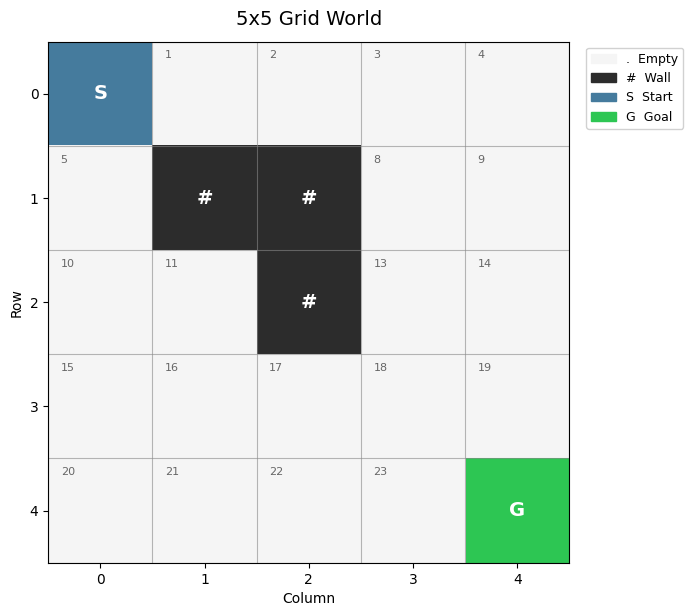

In [84]:
def plot_5grid(values=None, policy=None, title="5x5 Grid World"):
    grid_data = np.full((grid_size, grid_size), ".", dtype="<U1")

    for s in wall_states:
        r, c = state_to_pos(s)
        grid_data[r, c] = "#"

    r, c = state_to_pos(x_0)
    grid_data[r, c] = "S"

    r, c = state_to_pos(goal_grid)
    grid_data[r, c] = "G"

    mapping = {".": 0, "#": 1, "S": 2, "G": 3}
    labels = {0: "Empty", 1: "Wall", 2: "Start", 3: "Goal"}
    colors = ["#F5F5F5", "#2C2C2C", "#457B9D", "#2DC653"]

    numeric_grid = np.vectorize(mapping.get)(grid_data)
    cmap = mcolors.ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        numeric_grid,
        cmap=cmap,
        vmin=0,
        vmax=3,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="#888888", linewidth=0.8, alpha=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(np.arange(grid_size))
    ax.set_yticks(np.arange(grid_size))
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    if values is not None:
        if hasattr(values, "detach"):
            values = values.detach().cpu().numpy()
        values = np.asarray(values).reshape(-1)

    if policy is not None:
        if hasattr(policy, "detach"):
            policy = policy.detach().cpu().numpy()
        policy = np.asarray(policy)
        best_actions = policy.argmax(axis=1) if policy.ndim == 2 else policy

    arrow_delta = {
        0: (0.0, -0.28),  # Up
        1: (0.0, 0.28),   # Down
        2: (-0.28, 0.0),  # Left
        3: (0.28, 0.0),   # Right
    }

    for s in range(N):
        r, c = state_to_pos(s)

        if s == goal_grid:
            ax.text(c, r, "G", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s in wall_states:
            ax.text(c, r, "#", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s == x_0:
            ax.text(c, r, "S", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        else:
            ax.text(c - 0.38, r - 0.34, str(s), fontsize=8, color="#666666")

        if values is not None and s not in wall_states:
            ax.text(c, r + 0.28, f"{values[s]:.2f}", ha="center", va="center", fontsize=9)

        if policy is not None and s not in terminal_states and s not in wall_states:
            dx, dy = arrow_delta[int(best_actions[s])]
            ax.arrow(
                c,
                r,
                dx,
                dy,
                head_width=0.10,
                head_length=0.10,
                fc="black",
                ec="black",
                linewidth=1.4,
                length_includes_head=True,
                zorder=5,
            )

    patches = [
        mpatches.Patch(color=colors[i], label=f"{symbol}  {labels[i]}")
        for symbol, i in mapping.items()
    ]

    ax.legend(
        handles=patches,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    ax.set_title(title, fontsize=14, pad=12)
    plt.tight_layout()
    plt.show()


plot_5grid()

## Data collection

In [85]:
# Initialize the clean collector.
# every episode starts from state 0.
collector = DiscreteDataBuffer(
    mdp=mdp,
    reset_probs={"custom": 1.0},
    initial_states=[x_0],              
    restricted_states=wall_states,     
    max_steps=50,
    terminal_states={goal_grid},
    seed=SEED,
)

# Epsilon-greedy around the optimal policy.
# epsilon=0.3 means 70% planner.pi_star, 30% random action.
epsilon_policy = (planner.pi_star, 0.3)

df = collector.collect(
    policies=[epsilon_policy, "random"],
    proportions=[0.9, 0.1],
    n_steps=8000,
    extra_terminal_steps=3,
    episode_based=True,
    save_path=str(dataset_path_5grid),
    verbose=True,
)

df.head()

Collected 8000 transitions over 461 episodes.
Policy distribution:
policy_id
0    0.746
1    0.254
Name: proportion, dtype: float64
Reset mode distribution:
reset_mode
custom    1.0
Name: proportion, dtype: float64
Saved FOGAS dataset to /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets_clean/generalization/5grid.csv


,episode,step,state,action,reward,next_state,policy_id,reset_mode,restricted_start
0,0,0,0,1,-0.01,5,0,custom,False
1,0,1,5,1,-0.01,10,0,custom,False
2,0,2,10,3,-0.01,11,0,custom,False
3,0,3,11,1,-0.01,16,0,custom,False
4,0,4,16,1,-0.01,21,0,custom,False


## Solver

In [86]:
u_features = TabularFeatures(N, A)
q_features = TabularFeatures(N, A)
policy_features = TabularFeatures(N, A)

solver_e = FinalLinearSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path_5grid,
    u_function=LinearFunction(u_features),
    q_function=LinearQFunction(q_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,

    theta_include_beta_cov=False,

    theta_mode="reg_fixed",
    theta_lambda=1e-3,
    theta_optimizer="adam",
    theta_inner_steps=40,
    theta_lr=3e-1,
    theta_start_mode="warm",

    beta_update="fogas_full",
)

solver_e.run(
    alpha=1e-3,
    eta=1e-4,
    rho=0.05,
    policy_optimizer="adam",
    policy_gradient="reinforce",
    reinforce_samples=4,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=1000,
    state_weight_update="normal",
)

mdp.print_policy(solver_e.pi)

[FinalLinearSolver] Iter 1/1000 iter=0 total_loss=-2.334070e-02 policy_objective=-2.334070e-02 beta_objective=0.000000e+00 q_objective=-1.244493e-02 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=2.010787e-01 beta_direction_norm=5.251294e+00 theta_grad_norm=3.318592e-04 theta_norm=4.668141e+00 theta_mode=reg_fixed theta_optimizer=adam theta_start_mode=warm theta_lambda=1.000000e-03 theta_lr=3.000000e-01 theta_include_beta_cov=False policy_optimizer=adam policy_gradient=reinforce policy_direction=adam_gradient reinforce_samples=4 D_theta=1.000000e+02 effective_D_theta=1.000000e+02 beta_update=fogas_full beta_diag_min=None beta_diag_max=None
[FinalLinearSolver] Iter 51/1000 iter=50 total_loss=-1.966445e-02 policy_objective=-2.211270e-02 beta_objective=2.729373e-03 q_objective=-1.027049e-02 policy_grad_norm=2.632511e-04 policy_direction_norm=2.632511e-04 beta_grad_norm=1.523605e-01 beta_direction_norm=4.685963e+00 theta_grad_norm=1.031442e-04 theta_norm=4.

# 5 stochastic grid

In [75]:
states = torch.arange(25, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9
x_0 = 0

dataset_path_5grid_stoch = str(DATASETS_DIR / "5grid_stochastic.csv")

grid_size = 5
goal_grid = 24
pit_grid = 18

wall_states = {6, 7, 12}
terminal_states = {goal_grid, pit_grid}


def state_to_pos(s):
    return divmod(int(s), grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # Up
        new_row, new_col = row - 1, col
    elif a == 1:    # Down
        new_row, new_col = row + 1, col
    elif a == 2:    # Left
        new_row, new_col = row, col - 1
    elif a == 3:    # Right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0, 1, 2, 3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def transition_probs(s, a, intended_prob=0.8):
    """
    Stochastic transition:
    intended_prob goes to the requested action.
    The remaining probability is uniform over all actions.
    
    With intended_prob=0.8 and A=4:
      intended action: 0.8 + 0.2 / 4 = 0.85
      other actions:   0.2 / 4 = 0.05 each
    """
    s = int(s)
    a = int(a)

    probs_by_state = {}

    for candidate_a in range(A):
        prob = (1.0 - intended_prob) / A
        if candidate_a == a:
            prob += intended_prob

        sp = move_deterministic(s, candidate_a)
        probs_by_state[sp] = probs_by_state.get(sp, 0.0) + prob

    return probs_by_state


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)

    for sp, prob in transition_probs(s, a).items():
        probs[sp] = prob

    return probs


def next_state(s, a):
    """
    Sample one next state from the stochastic transition.
    Useful for manual rollouts, not used by DiscreteMDP planning.
    """
    probs = transition_fn(s, a)
    return int(torch.multinomial(probs.float(), num_samples=1).item())


def reward_from_next_state(sp):
    sp = int(sp)

    if sp == goal_grid:
        return 1.0

    if sp == pit_grid:
        return -1.0

    return -0.1


def reward_fn(s, a):
    """
    Expected one-step reward under P(. | s, a).
    """
    return sum(
        prob * reward_from_next_state(sp)
        for sp, prob in transition_probs(s, a).items()
    )


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    reward_fn=reward_fn,
    transition_fn=transition_fn,
    terminal_states=list(terminal_states),
).to(DEVICE)

planner = Planner(mdp)

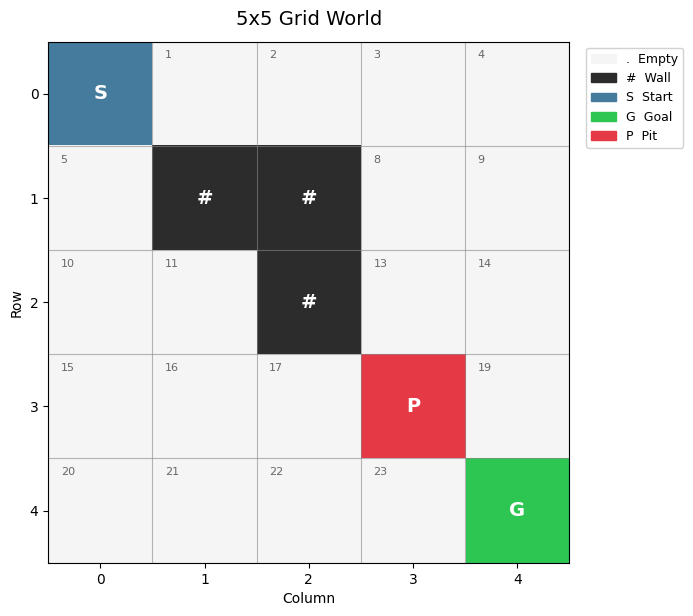

In [87]:
def plot_5grid(values=None, policy=None, title="5x5 Grid World"):
    grid_data = np.full((grid_size, grid_size), ".", dtype="<U1")

    for s in wall_states:
        r, c = state_to_pos(s)
        grid_data[r, c] = "#"

    r, c = state_to_pos(pit_grid)
    grid_data[r, c] = "P"

    r, c = state_to_pos(x_0)
    grid_data[r, c] = "S"

    r, c = state_to_pos(goal_grid)
    grid_data[r, c] = "G"

    mapping = {".": 0, "#": 1, "S": 2, "G": 3, "P": 4}
    labels = {0: "Empty", 1: "Wall", 2: "Start", 3: "Goal", 4: "Pit"}
    colors = ["#F5F5F5", "#2C2C2C", "#457B9D", "#2DC653", "#E63946"]

    numeric_grid = np.vectorize(mapping.get)(grid_data)
    cmap = mcolors.ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        numeric_grid,
        cmap=cmap,
        vmin=0,
        vmax=4,
        interpolation="nearest",
        origin="upper",
    )

    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="#888888", linewidth=0.8, alpha=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(np.arange(grid_size))
    ax.set_yticks(np.arange(grid_size))
    ax.set_xlabel("Column", fontsize=10)
    ax.set_ylabel("Row", fontsize=10)

    if values is not None:
        if hasattr(values, "detach"):
            values = values.detach().cpu().numpy()
        values = np.asarray(values).reshape(-1)

    if policy is not None:
        if hasattr(policy, "detach"):
            policy = policy.detach().cpu().numpy()
        policy = np.asarray(policy)
        best_actions = policy.argmax(axis=1) if policy.ndim == 2 else policy

    arrow_delta = {
        0: (0.0, -0.28),  # Up
        1: (0.0, 0.28),   # Down
        2: (-0.28, 0.0),  # Left
        3: (0.28, 0.0),   # Right
    }

    for s in range(N):
        r, c = state_to_pos(s)

        if s == goal_grid:
            ax.text(c, r, "G", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s == pit_grid:
            ax.text(c, r, "P", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s in wall_states:
            ax.text(c, r, "#", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        elif s == x_0:
            ax.text(c, r, "S", ha="center", va="center", fontsize=14, fontweight="bold", color="white")
        else:
            ax.text(c - 0.38, r - 0.34, str(s), fontsize=8, color="#666666")

        if values is not None and s not in wall_states:
            ax.text(c, r + 0.28, f"{values[s]:.2f}", ha="center", va="center", fontsize=9)

        if policy is not None and s not in terminal_states and s not in wall_states:
            dx, dy = arrow_delta[int(best_actions[s])]
            ax.arrow(
                c,
                r,
                dx,
                dy,
                head_width=0.10,
                head_length=0.10,
                fc="black",
                ec="black",
                linewidth=1.4,
                length_includes_head=True,
                zorder=5,
            )

    patches = [
        mpatches.Patch(color=colors[i], label=f"{symbol}  {labels[i]}")
        for symbol, i in mapping.items()
    ]

    ax.legend(
        handles=patches,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=9,
        framealpha=0.9,
    )

    ax.set_title(title, fontsize=14, pad=12)
    plt.tight_layout()
    plt.show()


plot_5grid()

## Data 

In [88]:
# Initialize the clean collector.
# every episode starts from state 0.
collector = DiscreteDataBuffer(
    mdp=mdp,
    reset_probs={"occupancy": 1.0},
    occupancy=planner.mu_star,          # shape N*A is accepted
    restricted_states=wall_states,
    max_steps=50,
    terminal_states={goal_grid},
    seed=SEED,
)

# Epsilon-greedy around the optimal policy.
# epsilon=0.3 means 70% planner.pi_star, 30% random action.
epsilon_policy = (planner.pi_star, 0.3)

df = collector.collect(
    policies=[epsilon_policy, "random"],
    proportions=[0.7, 0.3],
    n_steps=8000,
    extra_terminal_steps=3,
    episode_based=True,
    save_path=str(dataset_path_5grid_stoch),
    verbose=True,
)

df.head()

Collected 8000 transitions over 460 episodes.
Policy distribution:
policy_id
0    0.40425
1    0.59575
Name: proportion, dtype: float64
Reset mode distribution:
reset_mode
occupancy    1.0
Name: proportion, dtype: float64
Saved FOGAS dataset to /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets_clean/generalization/5grid_stochastic.csv


,episode,step,state,action,reward,next_state,policy_id,reset_mode,restricted_start
0,0,0,15,0,-0.01,10,1,occupancy,False
1,0,1,10,2,-0.01,10,1,occupancy,False
2,0,2,10,2,-0.01,10,1,occupancy,False
3,0,3,10,3,-0.01,11,1,occupancy,False
4,0,4,11,3,-0.01,11,1,occupancy,False


## Solver

In [89]:
u_features = TabularFeatures(N, A)
q_features = TabularFeatures(N, A)
policy_features = TabularFeatures(N, A)

solver_e = FinalLinearSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path_5grid,
    u_function=LinearFunction(u_features),
    q_function=LinearQFunction(q_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,

    theta_include_beta_cov=False,

    theta_mode="reg_fixed",
    theta_lambda=1e-3,
    theta_optimizer="adam",
    theta_inner_steps=40,
    theta_lr=3e-1,
    theta_start_mode="warm",

    beta_update="fogas_full",
)

solver_e.run(
    alpha=1e-3,
    eta=1e-4,
    rho=0.05,
    policy_optimizer="adam",
    policy_gradient="reinforce",
    reinforce_samples=4,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=1000,
    state_weight_update="normal",
)

mdp.print_policy(solver_e.pi)

[FinalLinearSolver] Iter 1/1000 iter=0 total_loss=-2.334070e-02 policy_objective=-2.334070e-02 beta_objective=0.000000e+00 q_objective=-1.244493e-02 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=2.010787e-01 beta_direction_norm=5.251294e+00 theta_grad_norm=3.318592e-04 theta_norm=4.668141e+00 theta_mode=reg_fixed theta_optimizer=adam theta_start_mode=warm theta_lambda=1.000000e-03 theta_lr=3.000000e-01 theta_include_beta_cov=False policy_optimizer=adam policy_gradient=reinforce policy_direction=adam_gradient reinforce_samples=4 D_theta=1.000000e+02 effective_D_theta=1.000000e+02 beta_update=fogas_full beta_diag_min=None beta_diag_max=None
[FinalLinearSolver] Iter 51/1000 iter=50 total_loss=-1.966445e-02 policy_objective=-2.211270e-02 beta_objective=2.729373e-03 q_objective=-1.027049e-02 policy_grad_norm=2.632511e-04 policy_direction_norm=2.632511e-04 beta_grad_norm=1.523605e-01 beta_direction_norm=4.685963e+00 theta_grad_norm=1.031442e-04 theta_norm=4.